# 22_因果机器学习-从 FWL 到 Double Lasso

## Notebook 使用说明

这是因果学习系列的第 11 份，也是“22. 因果机器学习”的第 1 份。建议先阅读“21. 因果推断基础”中的回归调整、AIPW 和 LaLonde 综合案例，并复习网站已有的 Lasso 回归。本篇需要 NumPy、pandas、Matplotlib、scikit-learn 和 statsmodels：`python -m pip install numpy pandas matplotlib scikit-learn statsmodels`。

FWL 定理依据参考资料 [1] 附录 B.3 和 [2] 第 1.4 节；Double Lasso、单次选择的反例、双重选择分别对应 [2] 第 4.2、4.3、4.5 节。Lasso 的惩罚和噪声估计按 [2] 第 3.1 节与附录 3.A 实现。这里保留原书的区别：Double Lasso 是分别残差化两侧，Double Selection 是取两个入选集合的并集后回归，两者不是有限样本下必然相等的算法。

主模拟沿用 [2] 例 4.3.1 的生成式，包括 $n=p=100$、系数 $1/j^2$ 和处理方程的噪声标准差 $1/4$；再增加 $n=p=400$ 的比较。小表、局部扰动、惩罚敏感性和稠密系数实验是另外设计的教学构造。所有数据由代码生成，不下载文件，也不依赖前面 Notebook 的变量或辅助模块。

本篇的 $T$ 是连续暴露，不是前面几篇的二元处理。主模拟估计线性结构中的单位暴露效应 $\theta_0=1$，不称为二元处理 ATE。默认做两种样本量下各 400 次独立重复模拟，另做两种系数结构下各 200 次模拟。代码输出与图形均已保存；重新运行请使用 Restart Kernel and Run All Cells，修改参数后以新的输出为准。

In [1]:
# 环境初始化：本篇只生成模拟数据，不读写外部数据文件。
import os
import sys
import tempfile
import warnings
from pathlib import Path
from statistics import NormalDist

os.environ.setdefault(
    "MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib")
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display
import sklearn
from sklearn.linear_model import Lasso
from sklearn.exceptions import ConvergenceWarning
import statsmodels
import statsmodels.api as sm

%matplotlib inline

_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [
    f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei",
                "SimHei", "Noto Sans CJK SC", "Noto Sans CJK JP"]
    if f in _available_fonts
] + ["DejaVu Sans"]
plt.rcParams.update({
    "font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
    "figure.dpi": 100, "figure.max_open_warning": 30,
})
pd.set_option("display.max_columns", 14)
pd.set_option("display.width", 140)

SEED_DATA = 42
SEED_TEST = 2026
SEED_REPEAT = 2027
SEED_DENSE = 2028
SEED_RANK = 2029
N_MAIN = 100
P_MAIN = 100
N_TEST = 10000
N_REPEATS = 400
SAMPLE_SIZES = (100, 400)
N_DENSE = 200
P_DENSE = 300
N_DENSE_REPEATS = 200
PENALTY_C = 1.1
PENALTY_TAIL = 0.05
MAX_SIGMA_STEPS = 60
SIGMA_RTOL = 1e-6
ALPHA_CI = 0.05
Z_CRIT = NormalDist().inv_cdf(1 - ALPHA_CI / 2)

print(f"Python {sys.version.split()[0]}")
print(f"NumPy {np.__version__} | pandas {pd.__version__} | Matplotlib {plt.matplotlib.__version__}")
print(f"scikit-learn {sklearn.__version__} | statsmodels {statsmodels.__version__}")

Python 3.13.5
NumPy 2.3.5 | pandas 2.2.3 | Matplotlib 3.10.8
scikit-learn 1.8.0 | statsmodels 0.14.6


前十篇已经把“调整哪些变量”和“怎样估计效应”分开讨论。现在增加一个实际困难：有很多候选控制变量，甚至变量比样本还多，普通回归放不下了。

一个自然的办法是先用 Lasso 筛选，再回归。但为预测结果而删去的一个小系数，可能恰好对应一个很能解释暴露的变量。它对预测的影响不大，对暴露系数的影响却可能很大。

先不急着换模型。我们从普通回归中的“控制其他变量”究竟怎么算开始，再把其中的预测步骤交给 Lasso。

## 理论基础

### 1. FWL：把控制变量能解释的部分先减去

用 $T$ 表示关心的暴露，$X$ 表示控制变量，$Y$ 表示结局。两本书的符号不同：[1] 附录使用 $X_1$ 表示目标列；[2] 使用 $D$ 表示目标变量、$W$ 表示控制变量。本篇统一记为 $T,X$，目标系数用 $\theta$，避免与软件的惩罚参数 `alpha` 混淆。

在同一份样本上，先用带截距的 OLS 分别拟合 $Y\sim X$ 和 $T\sim X$，得到

$$
r_Y=Y-\widehat Y_X,\qquad r_T=T-\widehat T_X.
$$

FWL 定理说：直接回归 $Y\sim T+X$ 的 $T$ 系数，等于把 $r_Y$ 对 $r_T$ 作无截距回归的斜率：

$$
\widehat\theta_{\mathrm{OLS}}
=\frac{\sum_i r_{T,i}r_{Y,i}}{\sum_i r_{T,i}^2}.
$$

两种算法给出同一个数，不是“近似相等”。前提是目标列还有剩余变异，系数能够唯一确定。这是回归的代数性质，本身并不证明因果关系。[1，定理 B.2；2，式 (1.4.3)]

还要注意一个不对称性：OLS 下，只残差化 $T$、把原始 $Y$ 回归到 $r_T$，也会得到同一斜率；只残差化 $Y$ 再回归到原始 $T$，一般不行。[1，附录 B.3] 下面会直接核对，后面再看为什么不能把这个 OLS 捷径原封不动搬到 Lasso。

## 完整案例一：把一个回归系数拆开算

### 1. 一张能逐行检查的小表

这里的 $X$ 是基础水平，$T$ 是额外学习时间。每个基础水平安排两个不同的学习时间，再按下面的规则生成结果。这个小表只用于核对回归代数，不把它当成一项真实研究。

In [2]:
def ols_residual(y: np.ndarray, design: np.ndarray) -> np.ndarray:
    """返回给定设计矩阵下的 OLS 残差；截距由调用者显式放入。"""
    y = np.asarray(y, dtype=float)
    design = np.asarray(design, dtype=float)
    if y.ndim != 1 or design.ndim != 2 or len(y) != len(design):
        raise ValueError("y 应为一维，设计矩阵应为二维，且行数相同。")
    if not np.isfinite(y).all() or not np.isfinite(design).all():
        raise ValueError("输入包含非有限值。")
    coef = np.linalg.lstsq(design, y, rcond=None)[0]
    return y - design @ coef

x_small = np.repeat(np.arange(-2, 4, dtype=float), 2)
v_small = np.tile([-0.5, 0.5], 6)
t_small = 2 - 0.5 * x_small + v_small
noise_small = np.repeat([0.2, -0.1, 0.3, -0.3, 0.1, -0.2], 2)
y_small = 10 + 1.5 * t_small + 2 * x_small + noise_small
C_small = np.column_stack([np.ones(len(x_small)), x_small])
r_t_small = ols_residual(t_small, C_small)
r_y_small = ols_residual(y_small, C_small)
full_small = sm.OLS(y_small, np.column_stack([C_small, t_small])).fit(cov_type="HC0")

small_table = pd.DataFrame({
    "基础水平 X": x_small, "学习时间 T": t_small, "结果 Y": y_small,
    "T 的拟合值": t_small - r_t_small, "T 的残差": r_t_small,
    "Y 的拟合值": y_small - r_y_small, "Y 的残差": r_y_small,
})
display(small_table.round(3))

small_slopes = pd.Series({
    "不调整 X": sm.OLS(y_small, sm.add_constant(t_small)).fit().params[1],
    "完整回归 Y ~ 1 + X + T": full_small.params[-1],
    "两侧残差化": r_t_small @ r_y_small / (r_t_small @ r_t_small),
    "只残差化 T": r_t_small @ y_small / (r_t_small @ r_t_small),
    "只残差化 Y，再用原始 T": sm.OLS(r_y_small, sm.add_constant(t_small)).fit().params[1],
}, name="斜率")
display(small_slopes.to_frame().round(6))
np.testing.assert_allclose(small_slopes.iloc[1:4], 1.5, atol=1e-12)
np.testing.assert_allclose(C_small.T @ r_t_small, 0, atol=1e-12)

,基础水平 X,学习时间 T,结果 Y,T 的拟合值,T 的残差,Y 的拟合值,Y 的残差
0,-2.0,2.5,9.95,3.0,-0.5,10.643,-0.693
1,-2.0,3.5,11.45,3.0,0.5,10.643,0.807
2,-1.0,2.0,10.90,2.5,-0.5,11.836,-0.936
3,-1.0,3.0,12.40,2.5,0.5,11.836,0.564
4,0.0,1.5,12.55,2.0,-0.5,13.029,-0.479
5,0.0,2.5,14.05,2.0,0.5,13.029,1.021
6,1.0,1.0,13.20,1.5,-0.5,14.221,-1.021
7,1.0,2.0,14.70,1.5,0.5,14.221,0.479
8,2.0,0.5,14.85,1.0,-0.5,15.414,-0.564
9,2.0,1.5,16.35,1.0,0.5,15.414,0.936


,斜率
不调整 X,-1.393617
完整回归 Y ~ 1 + X + T,1.500000
两侧残差化,1.500000
只残差化 T,1.500000
只残差化 Y，再用原始 T,0.382979


完整回归、两侧残差化和只残差化 $T$ 都得到 1.5。没有调整时的斜率是负的：这张表中基础水平较低的人恰好学习得更久，原始散点中的关系混合了两条路径。

残差的意思也很具体：$r_T=0.5$ 表示比这个基础水平的线性预测多学 0.5；不是把所有人的学习时间都减去同一个均值。图中的横轴已没有 $X$ 能线性解释的部分。

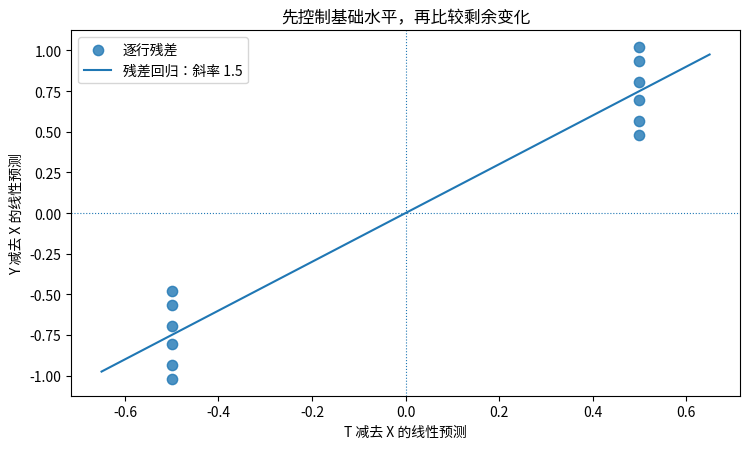

In [3]:
fig, ax = plt.subplots(figsize=(7.6, 4.6))
ax.scatter(r_t_small, r_y_small, s=55, alpha=0.8, label="逐行残差")
xline = np.array([-0.65, 0.65])
ax.plot(xline, small_slopes["两侧残差化"] * xline, label="残差回归：斜率 1.5")
ax.axhline(0, linewidth=0.8, linestyle=":")
ax.axvline(0, linewidth=0.8, linestyle=":")
ax.set(xlabel="T 减去 X 的线性预测", ylabel="Y 减去 X 的线性预测",
       title="先控制基础水平，再比较剩余变化")
ax.legend()
fig.tight_layout()
plt.show()

### 2. 为什么不能直接把所有变量放进 OLS？

若有 $p$ 个控制变量，完整回归还要放截距与 $T$。当设计矩阵的列数超过行数，系数通常不再唯一；当 $p/n$ 很大但小于 1，系数与常规标准误也可能不稳定。Lasso 通过约束系数复杂度，把高维预测变成一个可以求解的问题。[2，第 1.3、1.6、3.1 节]

但“预测可求解”不等于“目标系数可直接作推断”。要保留 FWL 的思路，先学两项辅助预测，而不是把 $T$ 的 Lasso 系数直接作为最终答案。

## 从 OLS 残差化到 Double Lasso

### 1. 分别预测 $Y$ 和 $T$

考虑原书的线性形式

$$
Y=\theta_0T+X^\top\beta+\epsilon,\qquad
T=X^\top\gamma+V.
$$

在下面独立噪声的模拟中，两个辅助条件均值为

$$
m_0(X)=E[T\mid X]=X^\top\gamma,\qquad
\ell_0(X)=E[Y\mid X]=X^\top(\theta_0\gamma+\beta).
$$

注意，预测 $Y\sim X$ 学到的是 $\ell_0$，不是结构式中的 $g_0(X)=X^\top\beta$。原书第 4 章更一般地将它们写成最佳线性预测；这里由于生成式是线性的，两种解释一致。[2，第 4.2 节]

分别拟合两个 Lasso，得到 $\widehat\ell,\widehat m$，然后计算

$$
\widehat r_{Y,i}=Y_i-\widehat\ell(X_i),\quad
\widehat r_{T,i}=T_i-\widehat m(X_i),\quad
\widehat\theta_{\mathrm{DL}}=
\frac{\sum_i\widehat r_{T,i}\widehat r_{Y,i}}
     {\sum_i\widehat r_{T,i}^2}.
$$

原书也允许用 Post-Lasso 替代两次 Lasso：先按非零系数选列，再在各自选中的列上重拟合 OLS。本篇同时保留直接 Lasso 与 Post-Lasso 的结果，主流程用 Post-Lasso，不把这两种实现混成同一个数。[2，第 4.2 节]

### 2. 与“双重选择”有什么区别？

设 $S_Y$ 为 $Y\sim X$ 的 Lasso 入选列，$S_T$ 为 $T\sim X$ 的入选列。双重选择再做一次

$$
Y\sim 1+T+X_{S_Y\cup S_T},
$$

读出 $T$ 的 OLS 系数。这里取并集，不是交集；$T$ 始终保留，也不在最后一步受惩罚。[2，第 4.5 节]

| 方法 | 先做什么 | 最后用什么估计目标系数 |
|---|---|---|
| 单次选择 | 对 $Y\sim T+X$ 做一次 Lasso | 强制保留 $T$，与入选控制变量一起做 OLS |
| Double Lasso | 分别拟合 $Y\sim X$、$T\sim X$ | 两侧残差之间的斜率 |
| Double Lasso：Post-Lasso 版本 | 两次 Lasso 后各自重拟合 OLS | 两侧 Post-Lasso 残差之间的斜率 |
| 双重选择 | 同样得到 $S_Y,S_T$ | 用并集 $S_Y\cup S_T$ 做完整 OLS |

Post-Lasso 的两个残差可能来自不同的控制集合；双重选择则对两侧使用同一个并集。因此后两行在某些数据上相等，在另一些数据上不同。原书说的是适当条件下近似等价，不是逐样本恒等式。

## 完整案例二：按原书生成式比较单次选择与双重调整

### 1. 数据生成规则和要估计的量

按 [2] 例 4.3.1，设置

$$
X\sim N(0,I_p),\quad \beta_j=\gamma_j=1/j^2,\quad
V\sim N(0,1)/4,\quad \epsilon\sim N(0,1),\quad\theta_0=1.
$$

$X,V,\epsilon$ 相互独立。`normal(..., scale=0.25)` 对应噪声标准差 0.25，不是方差 0.25。每个系数都非零，但尾部很快变小，所以这是近似稀疏，不是“只有前几个系数非零”。

作为因果模拟，再定义 $Y(t)=t+X^\top\beta+\epsilon$。改变 $t$ 一单位，$Y(t)$ 改变一单位；独立生成的误差保证了相应的外生性。这是对模拟赋予的结构解释，不是原书第 4 章中任意预测系数都能自动获得的解释。

In [4]:
def generate_data(n: int, p: int, seed, *, dense: bool = False):
    """观察量和教学真值分开返回；估计函数不接收真值。"""
    if not isinstance(n, (int, np.integer)) or not isinstance(p, (int, np.integer)):
        raise ValueError("n 和 p 必须为整数。")
    if n < 8 or p < 1:
        raise ValueError("至少需要 8 行和 1 个控制变量。")
    rng = np.random.default_rng(seed)
    X = rng.normal(size=(n, p))
    if dense:
        beta = np.full(p, 1 / np.sqrt(p))
    else:
        beta = 1 / np.arange(1, p + 1, dtype=float) ** 2
    gamma = beta.copy()
    theta = 1.0
    v = 0.25 * rng.normal(size=n)
    epsilon = rng.normal(size=n)
    t = X @ gamma + v
    y = theta * t + X @ beta + epsilon
    observed = {"X": X, "T": t, "Y": y}
    truth = {"theta": theta, "beta": beta, "gamma": gamma,
             "m": X @ gamma, "ell": X @ (theta * gamma + beta),
             "v": v, "epsilon": epsilon}
    return observed, truth

observed, truth = generate_data(N_MAIN, P_MAIN, SEED_DATA)
X, t, y = observed["X"], observed["T"], observed["Y"]
preview = pd.DataFrame(X[:, :5], columns=[f"X{j}" for j in range(1, min(5, P_MAIN) + 1)])
preview.insert(0, "T", t)
preview.insert(1, "Y", y)
print(f"主样本：n={len(y)}, p={X.shape[1]}；目标系数 theta={truth['theta']:.1f}")
display(preview.head(8).round(4))
print(f"前五项控制系数占 beta 平方和的比例：{np.sum(truth['beta'][:5]**2) / np.sum(truth['beta']**2):.4f}")

主样本：n=100, p=100；目标系数 theta=1.0


,T,Y,X1,X2,X3,X4,X5
0,0.1262,-0.6950,0.3047,-1.0400,0.7505,0.9406,-1.9510
1,0.1005,-1.0500,-0.3782,1.2992,-0.3563,0.7375,-0.9336
2,0.2386,0.6344,0.3376,1.4075,0.0906,0.6439,-2.0502
3,1.3855,1.1227,1.7274,-1.5339,0.8638,-0.3285,-0.0613
4,0.1055,0.2983,-0.1796,0.1968,0.8205,-0.3937,0.5212
5,1.3452,0.7687,1.3639,0.8952,-0.7195,-1.5025,-2.9645
6,0.8168,1.4284,0.5154,-0.5775,1.2744,-0.6276,-0.6366
7,0.5325,0.1078,1.1130,-0.2451,-1.0308,-0.0570,1.0492


前五项控制系数占 beta 平方和的比例：0.9982


### 2. 惩罚参数：先对齐书中公式与软件

原书的目标函数是残差平方和加 $\lambda\sum_j\widehat\psi_j|b_j|$，同方差设置下使用

$$
\lambda=2c\widehat\sigma\sqrt n\,z_{1-a/(2p)},
\qquad \widehat\psi_j=\sqrt{\frac1n\sum_i X_{ij}^2}.
$$

数据先中心化。将每列再除以自己的均方根，就可以使用等权惩罚。截距不受惩罚。[2，式 (3.1.3)–(3.1.4)]

scikit-learn 的 Lasso 最小化 $\|y-Xb\|^2/(2n)+\texttt{alpha}\|b\|_1$，所以标准化之后应传入

$$
\texttt{alpha}=\lambda/(2n)
=c\widehat\sigma z_{1-a/(2p)}/\sqrt n.
$$

这里的 $a=0.05$ 用于惩罚校准；后面区间的显著性水平另设为 `ALPHA_CI`，两者不是同一个任务。[2，第 3.1 节；3，软件目标函数]

下面按附录 3.A 用残差均方根迭代估计 $\sigma$，初值来自与目标最相关的至多五列的 OLS。相对停止阈值、最大迭代次数和输入检查是本篇的程序设置。Lasso 拟合与尺度迭代分开检查；没有收敛就报错，不忽略警告继续给出结果。

这套标量噪声公式适合本篇的独立同方差噪声。附录 3.A 对更一般情形另给了按残差构造逐列惩罚载荷的方法，本篇没有实现那一版，不能仅凭最后用了稳健标准误，就认为前面的惩罚也已处理异方差。

In [5]:
def fit_plugin_lasso(X: np.ndarray, y: np.ndarray, *, c: float = PENALTY_C,
                     tail: float = PENALTY_TAIL,
                     max_steps: int = MAX_SIGMA_STEPS) -> dict:
    """按书中同方差 plug-in 规则拟合，同时保存 Lasso 与 Post-Lasso 预测。"""
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    if X.ndim != 2 or y.ndim != 1 or len(X) != len(y):
        raise ValueError("X 应为二维、y 应为一维，且行数相同。")
    n, p = X.shape
    if n < 8 or p < 1 or not np.isfinite(X).all() or not np.isfinite(y).all():
        raise ValueError("样本过少、没有控制列，或输入包含非有限值。")
    if not np.isfinite(c) or c <= 0 or not 0 < tail < 1:
        raise ValueError("c 必须为正数，tail 必须在 (0, 1) 内。")
    if not isinstance(max_steps, (int, np.integer)) or max_steps < 1:
        raise ValueError("max_steps 必须为正整数。")
    center, scale = X.mean(axis=0), X.std(axis=0, ddof=0)
    if np.any(scale <= 1e-12):
        raise ValueError("请去掉常数控制列；函数内部处理截距。")
    Z = np.asfortranarray((X - center) / scale)
    yc = y - y.mean()
    if np.linalg.norm(yc) <= 1e-12:
        raise ValueError("目标没有变异，无需使用本例的噪声迭代。")

    initial = np.argsort(np.abs(Z.T @ yc), kind="stable")[-min(5, p, n // 4):]
    residual0 = ols_residual(yc, Z[:, initial])
    sigma = float(np.sqrt(np.mean(residual0 ** 2)))
    if sigma <= 1e-12:
        raise ValueError("初始残差近乎为零，不能用本例的噪声规则。")
    multiplier = c * NormalDist().inv_cdf(1 - tail / (2 * p)) / np.sqrt(n)
    history = []
    for step in range(1, max_steps + 1):
        alpha = multiplier * sigma
        learner = Lasso(alpha=alpha, fit_intercept=False, max_iter=20000,
                        tol=1e-9, selection="cyclic")
        with warnings.catch_warnings():
            warnings.simplefilter("error", ConvergenceWarning)
            learner.fit(Z, yc)
        residual = yc - learner.predict(Z)
        sigma_new = float(np.sqrt(np.mean(residual ** 2)))
        history.append((step, sigma, alpha, sigma_new))
        if abs(sigma_new - sigma) <= SIGMA_RTOL * max(sigma, 1.0):
            break
        sigma = sigma_new
    else:
        raise RuntimeError("噪声尺度迭代未收敛，请检查设定或增加 max_steps。")

    selected = np.flatnonzero(np.abs(learner.coef_) > 1e-10)
    post_coef_std = np.zeros(p)
    if len(selected):
        if len(selected) + 1 >= n:
            raise ValueError("入选列过多，Post-Lasso 不再是低维重拟合。")
        coef, _, rank, _ = np.linalg.lstsq(Z[:, selected], yc, rcond=None)
        if rank != len(selected):
            raise ValueError("入选列线性相关，无法唯一重拟合。")
        post_coef_std[selected] = coef

    result = {"selected": selected, "alpha": alpha, "sigma": sigma_new,
              "history": pd.DataFrame(history, columns=["迭代", "输入 sigma", "alpha", "残差 RMS"]),
              "solver_iterations": int(learner.n_iter_), "dual_gap": float(learner.dual_gap_)}
    for name, b_std in [("lasso", learner.coef_), ("post", post_coef_std)]:
        coef = b_std / scale
        intercept = float(y.mean() - center @ coef)
        result[name] = {"coef": coef.copy(), "intercept": intercept,
                        "fitted": intercept + X @ coef}
    return result

fit_y = fit_plugin_lasso(X, y)
fit_t = fit_plugin_lasso(X, t)
fit_joint = fit_plugin_lasso(np.column_stack([t, X]), y)
fit_trace = pd.concat([
    fit_y["history"].assign(目标="Y ~ X"),
    fit_t["history"].assign(目标="T ~ X"),
], ignore_index=True)
display(fit_trace.groupby("目标", sort=False).tail(3).round(6))
print("入选控制列（从 1 开始编号）")
print("Y ~ X：", (fit_y["selected"] + 1).tolist())
print("T ~ X：", (fit_t["selected"] + 1).tolist())

,迭代,输入 sigma,alpha,残差 RMS,目标
8,9,1.237325,0.473751,1.237336,Y ~ X
9,10,1.237336,0.473755,1.237339,Y ~ X
10,11,1.237339,0.473756,1.237340,Y ~ X
22,12,0.370026,0.141677,0.370029,T ~ X
23,13,0.370029,0.141678,0.370030,T ~ X
24,14,0.370030,0.141678,0.370030,T ~ X


入选控制列（从 1 开始编号）
Y ~ X： [1, 2]
T ~ X： [1, 2, 3]


### 3. 单次选择到底漏掉了什么？

单次选择按书中第 4.3 节的反例做：对 $Y\sim T+X$ 拟合 Lasso，保留其选中的控制变量，再强制加入 $T$ 做 OLS。这样即使 Lasso 把 $T$ 压到零，最终模型也不会偷偷换掉研究问题。

下面比较三个入选集合。`Y ~ X` 的系数描述 $X$ 对结果的总预测作用，`Y ~ T + X` 中控制列的系数是在已有 $T$ 后的额外预测作用，它们不能混为一谈。

,控制变量,结构系数 beta,T 的预测系数 gamma,Y~T+X 入选,Y~X 入选,T~X 入选
0,X1,1.00000,1.00000,True,True,True
1,X2,0.25000,0.25000,False,True,True
2,X3,0.11111,0.11111,False,False,True
3,X4,0.06250,0.06250,False,False,False
4,X5,0.04000,0.04000,False,False,False
5,X6,0.02778,0.02778,False,False,False
6,X7,0.02041,0.02041,False,False,False
7,X8,0.01562,0.01562,False,False,False
8,X9,0.01235,0.01235,False,False,False
9,X10,0.01000,0.01000,False,False,False


双重选择并集： [1, 2, 3]


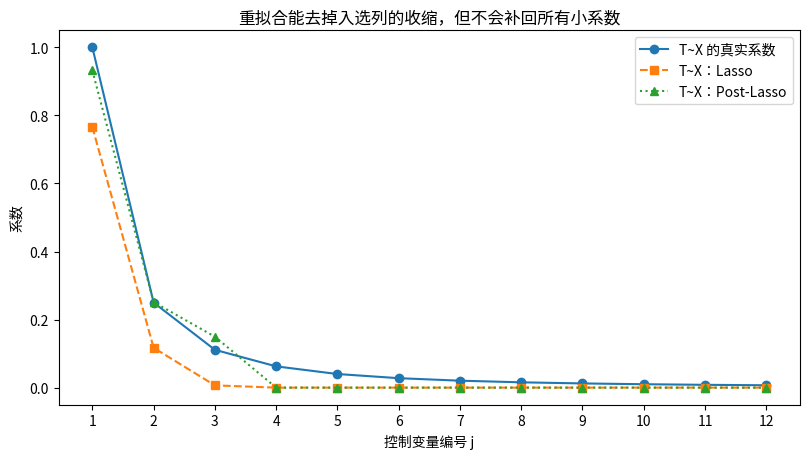

In [6]:
S_y = fit_y["selected"]
S_t = fit_t["selected"]
S_single = fit_joint["selected"][fit_joint["selected"] > 0] - 1
S_union = np.union1d(S_y, S_t)

selection_table = pd.DataFrame({
    "控制变量": [f"X{j}" for j in range(1, P_MAIN + 1)],
    "结构系数 beta": truth["beta"], "T 的预测系数 gamma": truth["gamma"],
    "Y~T+X 入选": np.isin(np.arange(P_MAIN), S_single),
    "Y~X 入选": np.isin(np.arange(P_MAIN), S_y),
    "T~X 入选": np.isin(np.arange(P_MAIN), S_t),
})
display(selection_table.head(10).round(5))
print("双重选择并集：", (S_union + 1).tolist())

j_show = np.arange(1, min(12, P_MAIN) + 1)
fig, ax = plt.subplots(figsize=(8.2, 4.7))
ax.plot(j_show, truth["gamma"][:len(j_show)], "o-", label="T~X 的真实系数")
ax.plot(j_show, fit_t["lasso"]["coef"][:len(j_show)], "s--", label="T~X：Lasso")
ax.plot(j_show, fit_t["post"]["coef"][:len(j_show)], "^:", label="T~X：Post-Lasso")
ax.set(xlabel="控制变量编号 j", ylabel="系数", xticks=j_show,
       title="重拟合能去掉入选列的收缩，但不会补回所有小系数")
ax.legend()
fig.tight_layout()
plt.show()

默认样本中，单次选择只保留 $X_1$；`Y ~ X` 保留 $X_1,X_2$，`T ~ X` 又补进 $X_3$。其余小系数仍可能漏掉；本篇不是要求恢复所有非零系数，而是观察两项辅助预测是否足够好。

Post-Lasso 只对已经入选的列重拟合。它不会自动找出真正的调整集，也不会把未测混杂变成已测混杂。[2，第 3.1、4.2 节]

### 4. 逐行保存预测，再计算残差斜率

先用 Post-Lasso 走一遍完整计算。最终拟合仍是无截距残差回归；这里的两项拟合都含不受惩罚的截距，所以残差样本均值接近零。

设 $\widehat u_i=\widehat r_{Y,i}-\widehat\theta\widehat r_{T,i}$。按第 4.2 节的公式，HC0 标准误可直接写成

$$
\widehat{\mathrm{SE}}_{\mathrm{HC0}}
=\frac{\sqrt{\sum_i\widehat r_{T,i}^2\widehat u_i^2}}
       {\sum_i\widehat r_{T,i}^2}.
$$

这与原书先计算渐近方差再除以 $n$ 是同一式子。这里不再额外乘一次 $1/\sqrt n$。它的推断依据需要近似稀疏、适当惩罚、足够的残差暴露变异及其他正则条件，不是任何两列残差都自带有效区间。[2，式 (4.2.4)、定理 4.2.1]

In [7]:
def slope_hc0(r_y: np.ndarray, r_t: np.ndarray) -> dict:
    """无截距残差回归：点估计与 HC0，不使用自由度修正。"""
    r_y, r_t = np.asarray(r_y, dtype=float), np.asarray(r_t, dtype=float)
    if r_y.ndim != 1 or r_t.ndim != 1 or r_y.shape != r_t.shape or len(r_y) < 3:
        raise ValueError("需要至少三个成对的一维残差。")
    if not np.isfinite(r_y).all() or not np.isfinite(r_t).all():
        raise ValueError("残差包含非有限值。")
    denominator = float(r_t @ r_t)
    if denominator <= 1e-12:
        raise ValueError("暴露残差几乎没有变异，斜率不可可靠计算。")
    estimate = float(r_t @ r_y / denominator)
    residual = r_y - estimate * r_t
    se = float(np.sqrt(np.sum((r_t * residual) ** 2)) / denominator)
    return {"estimate": estimate, "se": se,
            "lower": estimate - Z_CRIT * se, "upper": estimate + Z_CRIT * se,
            "residual": residual}


def ols_target(y: np.ndarray, t: np.ndarray, controls: np.ndarray) -> dict:
    """对 y ~ 1 + t + controls 做 OLS，并手算目标列的 HC0。"""
    y, t, controls = np.asarray(y, float), np.asarray(t, float), np.asarray(controls, float)
    if y.ndim != 1 or t.shape != y.shape or controls.ndim != 2 or len(controls) != len(y):
        raise ValueError("输入维度或行数不匹配。")
    B = np.column_stack([np.ones(len(y)), t, controls])
    if not np.isfinite(B).all() or not np.isfinite(y).all():
        raise ValueError("输入包含非有限值。")
    if B.shape[1] >= B.shape[0]:
        raise ValueError("本函数只对有剩余自由度的低维完整回归作推断。")
    b, _, rank, _ = np.linalg.lstsq(B, y, rcond=None)
    if rank != B.shape[1]:
        raise ValueError("设计矩阵不满列秩。")
    residual = y - B @ b
    target_row = np.linalg.pinv(B)[1]
    se = float(np.sqrt(np.sum((target_row * residual) ** 2)))
    estimate = float(b[1])
    return {"estimate": estimate, "se": se,
            "lower": estimate - Z_CRIT * se, "upper": estimate + Z_CRIT * se,
            "coef": b, "residual": residual}

r_y = y - fit_y["post"]["fitted"]
r_t = t - fit_t["post"]["fitted"]
dl_post = slope_hc0(r_y, r_t)
trace_table = pd.DataFrame({
    "Y": y, "T": t,
    "预测 ell": fit_y["post"]["fitted"], "预测 m": fit_t["post"]["fitted"],
    "Y 残差": r_y, "T 残差": r_t,
    "分子逐行项": r_t * r_y, "分母逐行项": r_t ** 2,
})
display(trace_table.head(8).round(5))
print(f"分子和={np.sum(r_t*r_y):.6f}；分母和={np.sum(r_t**2):.6f}")
print(f"Post-Lasso 残差斜率={dl_post['estimate']:.6f}；HC0 SE={dl_post['se']:.6f}")
reference_fit = sm.OLS(r_y, r_t[:, None]).fit(cov_type="HC0")
np.testing.assert_allclose(dl_post["estimate"], reference_fit.params[0], atol=1e-10)
np.testing.assert_allclose(dl_post["se"], reference_fit.bse[0], atol=1e-10)

,Y,T,预测 ell,预测 m,Y 残差,T 残差,分子逐行项,分母逐行项
0,-0.69500,0.12620,-0.01714,0.12037,-0.67786,0.00583,-0.00395,0.00003
1,-1.05002,0.10053,-0.17311,-0.09346,-0.87691,0.19399,-0.17011,0.03763
2,0.63440,0.23864,1.23795,0.66768,-0.60355,-0.42904,0.25895,0.18408
3,1.12275,1.38548,2.44201,1.33899,-1.31926,0.04649,-0.06133,0.00216
4,0.29826,0.10549,-0.33357,-0.00952,0.63183,0.11501,0.07267,0.01323
5,0.76866,1.34518,2.93595,1.37408,-2.16729,-0.02890,0.06264,0.00084
6,1.42845,0.81681,0.60807,0.51144,0.82038,0.30537,0.25052,0.09325
7,0.10775,0.53251,1.90412,0.80694,-1.79637,-0.27442,0.49297,0.07531


分子和=10.665118；分母和=7.831792
Post-Lasso 残差斜率=1.361772；HC0 SE=0.336761


### 5. 同一份样本，比较几种估计

“已知辅助函数”直接减去生成式中的 $\ell_0,m_0$，只用来展示理想参照；现实中不能调用。其他行只使用观察到的 $X,T,Y$。未调整与单次选择的区间也列出来，是为了随后检查它们能否覆盖目标，不是已经认可了其因果推断。

,估计,HC0 SE,95%下限,95%上限
未调整,1.91983,0.11087,1.70253,2.13713
单次选择,1.56505,0.25449,1.06626,2.06383
DL：Lasso,1.93157,0.27170,1.39905,2.46409
DL：Post-Lasso,1.36177,0.33676,0.70173,2.02181
双重选择,1.36177,0.33060,0.71382,2.00973
已知辅助函数,1.16330,0.36242,0.45296,1.87364


Post-Lasso 与双重选择的点估计差：8.882e-16


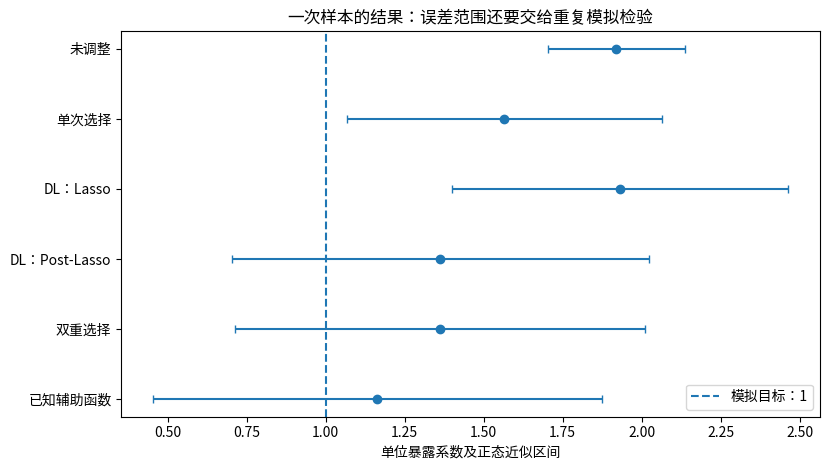

In [8]:
main_results = {
    "未调整": ols_target(y, t, np.empty((len(y), 0))),
    "单次选择": ols_target(y, t, X[:, S_single]),
    "DL：Lasso": slope_hc0(y - fit_y["lasso"]["fitted"], t - fit_t["lasso"]["fitted"]),
    "DL：Post-Lasso": dl_post,
    "双重选择": ols_target(y, t, X[:, S_union]),
    "已知辅助函数": slope_hc0(y - truth["ell"], t - truth["m"]),
}
main_table = pd.DataFrame({name: {k: v[k] for k in ["estimate", "se", "lower", "upper"]}
                           for name, v in main_results.items()}).T
main_table.columns = ["估计", "HC0 SE", "95%下限", "95%上限"]
display(main_table.round(5))
print(f"Post-Lasso 与双重选择的点估计差：{main_results['DL：Post-Lasso']['estimate'] - main_results['双重选择']['estimate']:.3e}")

fig, ax = plt.subplots(figsize=(8.4, 4.8))
positions = np.arange(len(main_table))
ax.errorbar(main_table["估计"], positions, xerr=Z_CRIT * main_table["HC0 SE"],
            fmt="o", capsize=3)
ax.axvline(truth["theta"], linestyle="--", label="模拟目标：1")
ax.set(yticks=positions, yticklabels=main_table.index, xlabel="单位暴露系数及正态近似区间",
       title="一次样本的结果：误差范围还要交给重复模拟检验")
ax.invert_yaxis()
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

默认样本中，单次选择约为 1.565，Post-Lasso 与双重选择都是约 1.362，已知辅助函数约为 1.163。直接使用带收缩的 Lasso 残差则约为 1.932，并没有优于单次选择。

Post-Lasso 与双重选择这次恰好得到相同点估计，但它们的 HC0 标准误仍略有差别：两个方法的最终回归残差不完全相同。这里保留直接 Lasso 的结果，不将“正交”写成“有限样本没有偏差”。

### 6. 预测得不错，是否就说明系数估计得好？

下面另外生成一份独立测试数据，只在已经固定的几个拟合之间比较预测误差，不据此重新选参数。对残差法，把预测式写成

$$
\widehat Y(t,x)=\widehat\ell(x)+\widehat\theta\{t-\widehat m(x)\}.
$$

这里的 $R^2$ 使用测试集围绕其自身均值的平方和。预测表是本篇对原书“预测与系数推断不同”这一问题的实验补充。

In [9]:
def predict_auxiliary(fit: dict, X_new: np.ndarray, kind: str = "post") -> np.ndarray:
    X_new = np.asarray(X_new, dtype=float)
    if kind not in ("lasso", "post"):
        raise ValueError("kind 应为 lasso 或 post。")
    b = fit[kind]
    if X_new.ndim != 2 or X_new.shape[1] != len(b["coef"]) or not np.isfinite(X_new).all():
        raise ValueError("新数据列数不匹配，或包含非有限值。")
    return b["intercept"] + X_new @ b["coef"]

new_obs, _ = generate_data(N_TEST, P_MAIN, SEED_TEST)
X_test, t_test, y_test = new_obs["X"], new_obs["T"], new_obs["Y"]
predictions = {
    "单次选择": np.column_stack([np.ones(N_TEST), t_test, X_test[:, S_single]]) @ main_results["单次选择"]["coef"],
    "双重选择": np.column_stack([np.ones(N_TEST), t_test, X_test[:, S_union]]) @ main_results["双重选择"]["coef"],
}
for method, kind in [("DL：Lasso", "lasso"), ("DL：Post-Lasso", "post")]:
    predictions[method] = (predict_auxiliary(fit_y, X_test, kind)
        + main_results[method]["estimate"] * (t_test - predict_auxiliary(fit_t, X_test, kind)))
prediction_rows = []
for name, predicted in predictions.items():
    mse = float(np.mean((y_test - predicted) ** 2))
    prediction_rows.append({"方法": name, "测试 MSE": mse,
        "测试 R2": 1 - mse / np.var(y_test),
        "目标系数估计": main_results[name]["estimate"],
        "系数绝对误差": abs(main_results[name]["estimate"] - truth["theta"])})
prediction_table = pd.DataFrame(prediction_rows).set_index("方法")
display(prediction_table.round(5))

,测试 MSE,测试 R2,目标系数估计,系数绝对误差
方法,,,,
单次选择,1.06211,0.80676,1.56505,0.56505
双重选择,1.05451,0.80814,1.36177,0.36177
DL：Lasso,1.18405,0.78457,1.93157,0.93157
DL：Post-Lasso,1.11493,0.79714,1.36177,0.36177


默认结果中，单次选择的测试 MSE 约为 1.062，双重选择约为 1.055；预测表现很接近，目标系数的误差却不同。

预测表与系数表评价的是不同目标。这里大部分 $T$ 的变化本来就能由 $X$ 解释，预测 $Y$ 时，两者可以在一定程度上互相代替；估计“保持 $X$ 不变时，$T$ 改变一单位的作用”时，这种替代就不能忽略。

一次测试集结果不能证明某种方法普遍更好。下面重新生成整个训练样本，而不是重复使用同一数据换随机种子拟合。

## 模型分析：重复抽样中的偏差与区间

### 1. 每次都重新选择变量并拟合

保留原书的 $n=p=100$，再增加 $n=p=400$。第二种设置同时增加样本量与候选变量数；不是固定 $p$ 下只增加 $n$。两种设置都使用 $1/j^2$ 的系数衰减。

每次先拟合三项 Lasso，再得到单次选择、直接残差化、Post-Lasso 残差化与双重选择。用同一份观察数据比较方法，已知辅助函数只用于参照。重复模拟不需要 Bootstrap，也不把一次选择的列固定后重复拟合。

In [10]:
METHODS = ["单次选择", "DL：Lasso", "DL：Post-Lasso", "双重选择", "已知辅助函数"]

def estimate_methods(data: dict, *, c: float = PENALTY_C) -> tuple[dict, dict]:
    """可行估计仅接收观察数据，不接收生成系数或噪声。"""
    X, t, y = data["X"], data["T"], data["Y"]
    fy = fit_plugin_lasso(X, y, c=c)
    ft = fit_plugin_lasso(X, t, c=c)
    fj = fit_plugin_lasso(np.column_stack([t, X]), y, c=c)
    single = fj["selected"][fj["selected"] > 0] - 1
    union = np.union1d(fy["selected"], ft["selected"])
    results = {
        "单次选择": ols_target(y, t, X[:, single]),
        "DL：Lasso": slope_hc0(y-fy["lasso"]["fitted"], t-ft["lasso"]["fitted"]),
        "DL：Post-Lasso": slope_hc0(y-fy["post"]["fitted"], t-ft["post"]["fitted"]),
        "双重选择": ols_target(y, t, X[:, union]),
    }
    counts = {"单次选择列数": len(single), "Y侧列数": len(fy["selected"]),
              "T侧列数": len(ft["selected"]), "并集列数": len(union)}
    return results, counts

repeat_rows, selected_rows = [], []
seed_streams = np.random.SeedSequence(SEED_REPEAT).spawn(len(SAMPLE_SIZES))
for n, stream in zip(SAMPLE_SIZES, seed_streams):
    for b, seed in enumerate(stream.spawn(N_REPEATS)):
        data_b, truth_b = generate_data(n, n, seed)
        results_b, counts_b = estimate_methods(data_b)
        results_b["已知辅助函数"] = slope_hc0(
            data_b["Y"]-truth_b["ell"], data_b["T"]-truth_b["m"])
        for name in METHODS:
            result = results_b[name]
            repeat_rows.append({"n=p": n, "重复": b, "方法": name,
                "估计": result["estimate"], "SE": result["se"],
                "覆盖": result["lower"] <= truth_b["theta"] <= result["upper"]})
        selected_rows.append({"n=p": n, "重复": b, **counts_b})
    print(f"完成 n=p={n}：{N_REPEATS} 份独立样本，所有方法使用相同样本。")
repeats = pd.DataFrame(repeat_rows)
selected_repeats = pd.DataFrame(selected_rows)

完成 n=p=100：400 份独立样本，所有方法使用相同样本。


完成 n=p=400：400 份独立样本，所有方法使用相同样本。


### 2. 估计分布是否以目标为中心？

用平均估计减去 1 计算模拟偏差；用多次估计的标准差描述实际波动。`偏差 MCSE` 是模拟均值的 Monte Carlo 标准误，等于模拟标准差除以重复次数的平方根；它不是单份研究的效应标准误。

,n=p,方法,重复数,平均估计,偏差,偏差 MCSE,模拟 SD,平均 SE,RMSE,覆盖率
0,100,单次选择,400,1.5782,0.5782,0.0140,0.2807,0.2263,0.6426,0.4300
1,100,DL：Lasso,400,1.9241,0.9241,0.0156,0.3122,0.3149,0.9753,0.1550
2,100,DL：Post-Lasso,400,1.1930,0.1930,0.0186,0.3714,0.3759,0.4182,0.9100
3,100,双重选择,400,1.1935,0.1935,0.0186,0.3712,0.3611,0.4182,0.8850
4,100,已知辅助函数,400,0.9842,-0.0158,0.0192,0.3830,0.3983,0.3829,0.9625
5,400,单次选择,400,1.5628,0.5628,0.0074,0.1485,0.1306,0.5820,0.0200
6,400,DL：Lasso,400,1.4655,0.4655,0.0089,0.1778,0.1823,0.4982,0.2675
7,400,DL：Post-Lasso,400,1.0695,0.0695,0.0100,0.1998,0.1960,0.2114,0.9250
8,400,双重选择,400,1.0697,0.0697,0.0100,0.2000,0.1927,0.2116,0.9200
9,400,已知辅助函数,400,1.0014,0.0014,0.0102,0.2042,0.1989,0.2039,0.9550


,单次选择列数,Y侧列数,T侧列数,并集列数
n=p,,,,
100,0.78,1.59,2.26,2.27
400,1.00,2.42,3.66,3.67


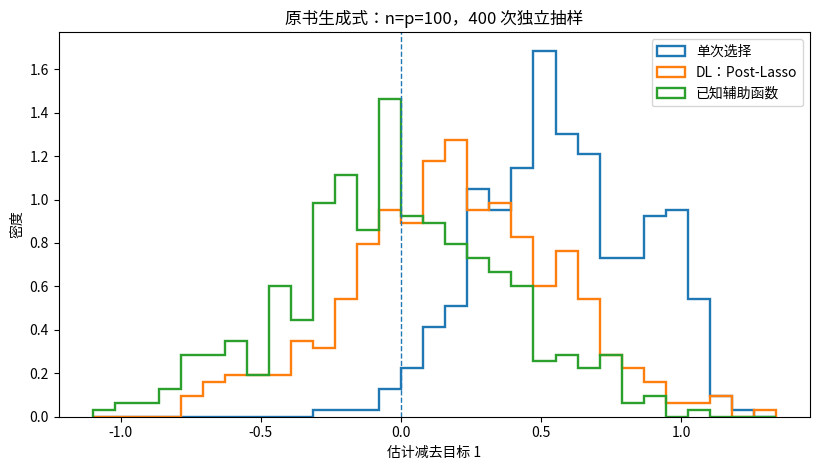

In [11]:
def summarize_simulation(frame: pd.DataFrame, groups: list[str]) -> pd.DataFrame:
    rows = []
    for key, part in frame.groupby(groups, sort=False):
        if not isinstance(key, tuple):
            key = (key,)
        estimates = part["估计"].to_numpy()
        sd = float(estimates.std(ddof=1))
        rows.append(dict(zip(groups, key)) | {
            "重复数": len(part), "平均估计": estimates.mean(),
            "偏差": estimates.mean()-1, "偏差 MCSE": sd/np.sqrt(len(part)),
            "模拟 SD": sd, "平均 SE": part["SE"].mean(),
            "RMSE": np.sqrt(np.mean((estimates-1)**2)), "覆盖率": part["覆盖"].mean()})
    return pd.DataFrame(rows)

repeat_summary = summarize_simulation(repeats, ["n=p", "方法"])
display(repeat_summary.round(4))
display(selected_repeats.drop(columns="重复").groupby("n=p").mean().round(2))

fig, ax = plt.subplots(figsize=(8.3, 4.8))
subset = repeats[repeats["n=p"] == SAMPLE_SIZES[0]]
shown_methods = ["单次选择", "DL：Post-Lasso", "已知辅助函数"]
all_errors = subset[subset["方法"].isin(shown_methods)]["估计"].to_numpy() - 1
bins = np.linspace(all_errors.min()-0.05, all_errors.max()+0.05, 32)
for method in shown_methods:
    errors = subset.loc[subset["方法"] == method, "估计"].to_numpy()-1
    ax.hist(errors, bins=bins, density=True, histtype="step", linewidth=1.7, label=method)
ax.axvline(0, linestyle="--", linewidth=1)
ax.set(xlabel="估计减去目标 1", ylabel="密度",
       title=f"原书生成式：n=p={SAMPLE_SIZES[0]}，{N_REPEATS} 次独立抽样")
ax.legend()
fig.tight_layout()
plt.show()

默认 400 次模拟中，单次选择在 $n=p=100$ 和 400 时的偏差分别约为 0.578 和 0.563；Post-Lasso 分别约为 0.193 和 0.069。后者更接近目标，但剩余偏差相对于其 Monte Carlo 标准误仍不小，不能称为已经无偏。直接 Lasso 的偏差约为 0.924 和 0.466，有限样本收缩影响更明显。

单次选择从 100 到 400 的偏差没有明显减少，不表示它永远不会收敛；这里同时增加了候选变量数，而且两种有限样本设置不足以决定渐近趋势。

这不是对原书图 4.1 柱形高度的逐点复现。这里按书中生成式重新抽样，并明确给出噪声尺度迭代、Lasso/Post-Lasso 的实现选择与所有模拟统计量；它们共同决定有限样本结果。

### 3. 95% 区间实际覆盖了多少次？

覆盖率是各次区间包含 $\theta_0=1$ 的比例。图中的误差线是该覆盖比例的 Wilson 区间，用来显示 400 次模拟自身的精度；它不是效应估计的区间。这一显示属于本篇的模拟诊断补充。

,n=p,方法,次数,覆盖率,Wilson下限,Wilson上限
0,100,单次选择,172/400,0.4300,0.3824,0.4790
1,100,DL：Lasso,62/400,0.1550,0.1228,0.1937
2,100,DL：Post-Lasso,364/400,0.9100,0.8779,0.9343
3,100,双重选择,354/400,0.8850,0.8500,0.9127
4,100,已知辅助函数,385/400,0.9625,0.9391,0.9771
5,400,单次选择,8/400,0.0200,0.0102,0.0390
6,400,DL：Lasso,107/400,0.2675,0.2265,0.3129
7,400,DL：Post-Lasso,370/400,0.9250,0.8950,0.9470
8,400,双重选择,368/400,0.9200,0.8892,0.9428
9,400,已知辅助函数,382/400,0.9550,0.9300,0.9713


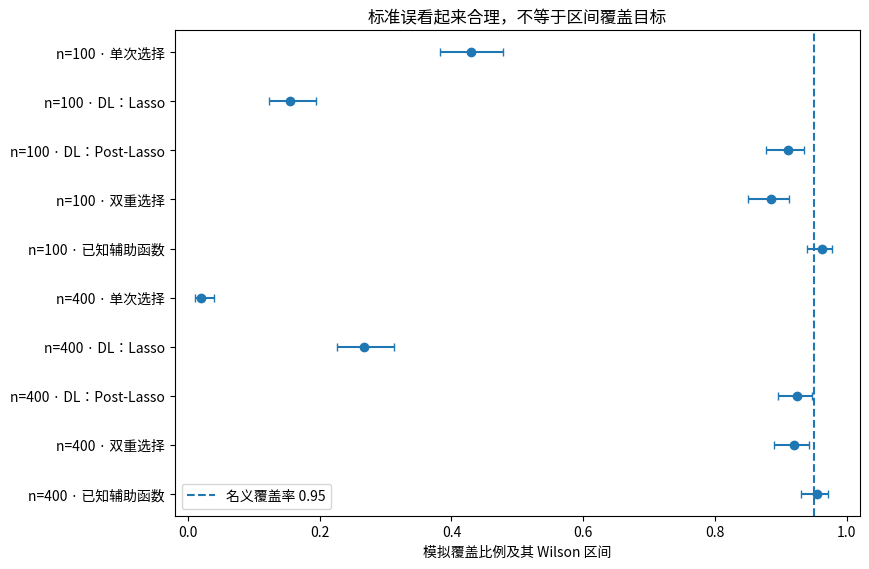

In [12]:
def wilson_interval(successes: int, total: int, z: float = Z_CRIT) -> tuple[float, float]:
    if total < 1 or not 0 <= successes <= total:
        raise ValueError("需要 0 <= successes <= total，且 total 为正。")
    proportion = successes / total
    den = 1 + z*z/total
    center = (proportion + z*z/(2*total))/den
    half = z*np.sqrt(proportion*(1-proportion)/total + z*z/(4*total*total))/den
    return center-half, center+half

coverage_rows = []
for (n, method), part in repeats.groupby(["n=p", "方法"], sort=False):
    k, total = int(part["覆盖"].sum()), len(part)
    lo, hi = wilson_interval(k, total)
    coverage_rows.append({"n=p": n, "方法": method, "次数": f"{k}/{total}",
                          "覆盖率": k/total, "Wilson下限": lo, "Wilson上限": hi})
coverage_table = pd.DataFrame(coverage_rows)
display(coverage_table.round(4))

fig, ax = plt.subplots(figsize=(8.8, 5.8))
positions = np.arange(len(coverage_table))
p_hat = coverage_table["覆盖率"].to_numpy()
err = np.vstack([p_hat-coverage_table["Wilson下限"], coverage_table["Wilson上限"]-p_hat])
ax.errorbar(p_hat, positions, xerr=np.maximum(err, 0), fmt="o", capsize=3)
ax.axvline(0.95, linestyle="--", label="名义覆盖率 0.95")
ax.set(yticks=positions,
       yticklabels=[f"n={row['n=p']} · {row['方法']}" for _, row in coverage_table.iterrows()],
       xlabel="模拟覆盖比例及其 Wilson 区间", xlim=(-0.02, 1.02),
       title="标准误看起来合理，不等于区间覆盖目标")
ax.invert_yaxis()
ax.legend(loc="lower left")
fig.tight_layout()
plt.show()

Post-Lasso 的覆盖率为 364/400=0.910 和 370/400=0.925；双重选择为 0.885 和 0.920。它们明显好于这两个设置下的单次选择，但没有达到名义 95%。直接 Lasso 的覆盖率更低，说明不能只从“平均 SE 接近模拟 SD”判断区间可靠：分布中心还可能偏移。

把 SE 乘一个系数，并不能自动解决遗漏变量或收缩偏差。即便已知辅助函数，正态近似也不是有限样本精确推断。下面用总体扰动公式解释为什么正交方法仍会留下这类误差。

## 为什么双侧残差化更能容忍小误差？

### 1. Neyman 正交性：看目标对辅助误差是否一阶敏感

Double Lasso 使用的总体矩条件是

$$
M(\theta,\ell,m)=E[(T-m(X))\{Y-\ell(X)-\theta(T-m(X))\}].
$$

在真实辅助函数附近，对 $\ell,m$ 作很小的改动，目标的变化没有一阶项，这就是本篇要理解的 Neyman 正交性。[2，第 4.3 节]

用一个另外构造的单控制变量模型算得更清楚：令 $X,V,\epsilon$ 独立、均值为零、方差为 1，$T=X+V$、$Y=T+X+\epsilon$，因此 $m_0(X)=X$、$\ell_0(X)=2X$。设

$$
\ell_a(X)=\ell_0(X)+aX,\qquad m_b(X)=m_0(X)+bX.
$$

此时残差是 $V-bX$ 与 $V+\epsilon-aX$。直接计算总体斜率得

$$
\theta(a,b)=\frac{1+ab}{1+b^2},\qquad
\theta(a,b)-1=\frac{ab-b^2}{1+b^2}.
$$

沿 $a=2h,b=h$，误差为 $h^2/(1+h^2)$；若改成先减去有误差的结构函数 $g_h(X)=(1+h)X$，再用原始 $T$ 回归，则斜率误差是 $-h/2$。前者从二次项开始，后者是一阶变化。这是本篇对正交性定义的代数演示，不是原书例 4.3.1 的另一种记法。

,h,双侧残差化误差,未残差化T的误差
0,0.200,0.038462,-0.1000
1,0.100,0.009901,-0.0500
2,0.050,0.002494,-0.0250
3,0.025,0.000625,-0.0125


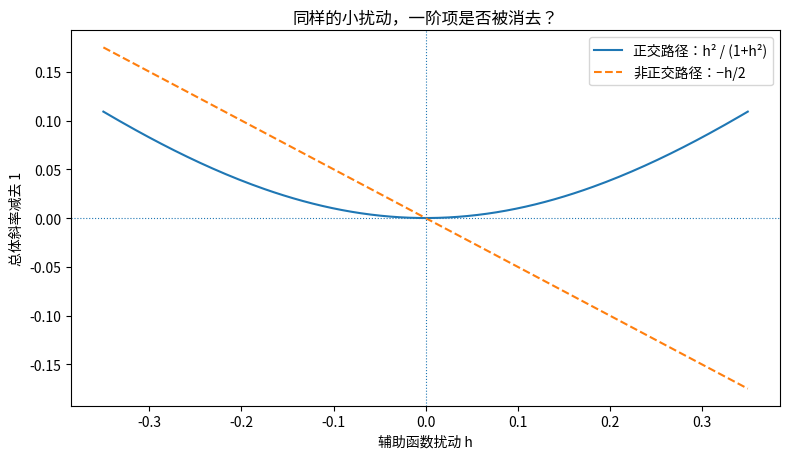

In [13]:
h_grid = np.linspace(-0.35, 0.35, 201)
orthogonal_error = h_grid**2 / (1+h_grid**2)
naive_error = -h_grid/2
h_values = np.array([0.2, 0.1, 0.05, 0.025])
perturbation_table = pd.DataFrame({
    "h": h_values, "双侧残差化误差": h_values**2/(1+h_values**2),
    "未残差化T的误差": -h_values/2,
})
display(perturbation_table.round(7))

fig, ax = plt.subplots(figsize=(8.0, 4.7))
ax.plot(h_grid, orthogonal_error, label="正交路径：h² / (1+h²)")
ax.plot(h_grid, naive_error, linestyle="--", label="非正交路径：−h/2")
ax.axhline(0, linewidth=0.8, linestyle=":")
ax.axvline(0, linewidth=0.8, linestyle=":")
ax.set(xlabel="辅助函数扰动 h", ylabel="总体斜率减去 1",
       title="同样的小扰动，一阶项是否被消去？")
ax.legend()
fig.tight_layout()
plt.show()

# 用独立的总体协方差运算核对，不依赖随机近似。
for a, b in [(0.1, 0.2), (0.3, 0.0), (0.0, 0.2), (-0.2, 0.4)]:
    cov_xy = np.dot([-b, 1, 0], [-a, 1, 1])
    var_t = np.dot([-b, 1, 0], [-b, 1, 0])
    np.testing.assert_allclose(cov_xy/var_t-1, (a*b-b*b)/(1+b*b), atol=1e-12)

这个公式也说明：正交性不是第八篇 AIPW 的那句“有一类模型正确即可”。这里若 $b=0$，斜率确实为 1；但若仅 $a=0$ 而 $b\ne0$，仍有 $-b^2/(1+b^2)$ 的误差。它强调在真实值附近的局部不敏感，不是任意错设下的双重稳健。

一阶项消失还不够。如果残差暴露方差很小，或者辅助误差并不小，高阶项依然能主导结果。主模拟中 $V$ 的方差只有 $1/16$，因而很适合观察这一点。

### 2. 保持数据不变，改变惩罚强度

下面只改变 `c`，每次完整重做尺度迭代、选择与估计。`c=0.55,0.8` 是故意减弱惩罚的诊断点，不满足原书校准式要求的 $c>1$；其他值也不是按“最接近真值”选出来的最佳参数。横轴变化用于观察敏感性，不生成算法排名。

,c,单次选择列数,Y侧列数,T侧列数,并集列数,单次选择,DL：Lasso,DL：Post-Lasso,双重选择
0,0.55,4,12,8,17,1.5663,1.5956,1.0133,1.2211
1,0.80,1,2,4,4,1.5650,1.8021,1.5274,1.5274
2,1.10,1,2,3,3,1.5650,1.9316,1.3618,1.3618
3,1.50,1,1,2,2,1.5650,1.9427,1.3012,1.3012
4,2.20,0,1,1,1,1.9198,2.2868,1.5650,1.5650
5,3.30,0,0,0,0,1.9198,1.9198,1.9198,1.9198


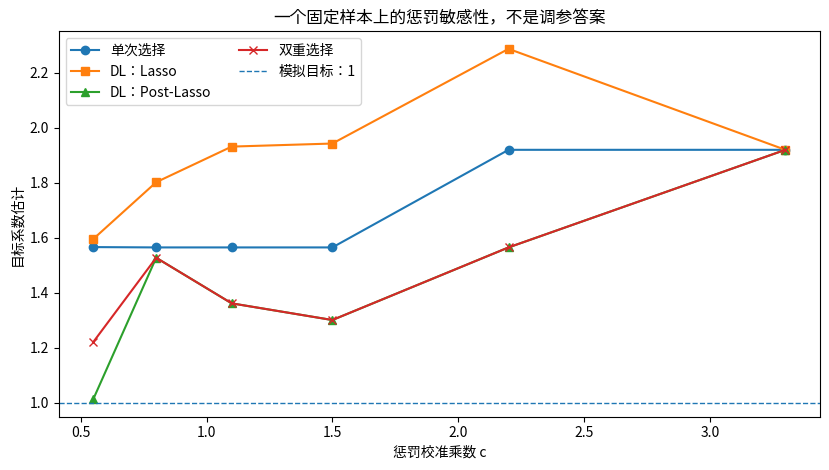

In [14]:
penalty_values = (0.55, 0.8, 1.1, 1.5, 2.2, 3.3)
penalty_rows = []
for c in penalty_values:
    result, counts = estimate_methods(observed, c=c)
    row = {"c": c, **counts}
    row.update({name: val["estimate"] for name, val in result.items()})
    penalty_rows.append(row)
penalty_table = pd.DataFrame(penalty_rows)
display(penalty_table.round(4))

fig, ax = plt.subplots(figsize=(8.4, 4.8))
for name, marker in [("单次选择", "o"), ("DL：Lasso", "s"),
                     ("DL：Post-Lasso", "^"), ("双重选择", "x")]:
    ax.plot(penalty_table["c"], penalty_table[name], marker=marker, label=name)
ax.axhline(1, linestyle="--", linewidth=1, label="模拟目标：1")
ax.set(xlabel="惩罚校准乘数 c", ylabel="目标系数估计",
       title="一个固定样本上的惩罚敏感性，不是调参答案")
ax.legend(ncol=2)
fig.tight_layout()
plt.show()

曲线不必单调，原因包括入选集合的离散变化与两项残差同时变化。较大的惩罚可能压掉有用变量；较小的惩罚则可能把样本噪声拟合进去。原书提醒，直接使用交叉验证 Lasso 作同样本残差化，在中等样本里也可能过拟合。[2，第 4.2 节]

下一份才引入交叉拟合。本篇的计算依赖 Lasso 这一特定模型的结构和惩罚控制，不据此将两个预测步骤直接改成任意随机森林或神经网络。

## 失败情形：很多小作用不再能忽略

另外生成一个稠密模型，改成 $\beta_j=\gamma_j=1/\sqrt p$，其他噪声设置不变。这时每个系数都小，但所有小系数的平方和为 1；仅保留少量变量会丢掉大部分信号。这不是前面 $1/j^2$ 的近似稀疏结构。

两种结构都设置 $n=200,p=300$，各抽取 200 份独立数据。这个比较是本篇的压力测试，不来自书中某张表。已知辅助函数依然可用，因此也能区分“估计目标本身困难”和“辅助函数学不好”。

完成 快速衰减 1/j²：200 份独立样本。


完成 稠密 1/√p：200 份独立样本。


,结构,方法,重复数,平均估计,偏差,偏差 MCSE,模拟 SD,平均 SE,RMSE,覆盖率
0,快速衰减 1/j²,DL：Post-Lasso,200,1.1140,0.1140,0.0207,0.2924,0.2751,0.3132,0.905
1,快速衰减 1/j²,双重选择,200,1.1147,0.1147,0.0206,0.2919,0.2678,0.3130,0.910
2,快速衰减 1/j²,已知辅助函数,200,0.9997,-0.0003,0.0211,0.2978,0.2832,0.2971,0.930
3,稠密 1/√p,DL：Post-Lasso,200,1.9261,0.9261,0.0056,0.0792,0.0707,0.9295,0.000
4,稠密 1/√p,双重选择,200,1.9341,0.9341,0.0048,0.0676,0.0703,0.9366,0.000
5,稠密 1/√p,已知辅助函数,200,0.9803,-0.0197,0.0209,0.2957,0.2816,0.2956,0.945


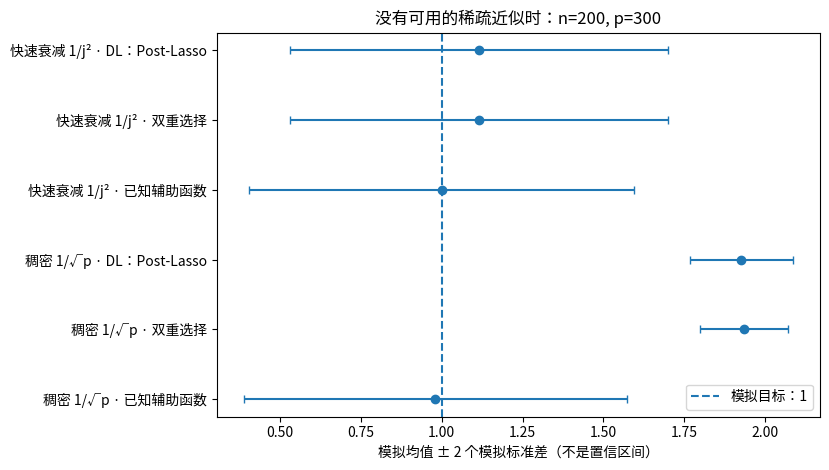

In [15]:
dense_rows = []
dense_streams = np.random.SeedSequence(SEED_DENSE).spawn(2)
for label, dense, stream in zip(["快速衰减 1/j²", "稠密 1/√p"], [False, True], dense_streams):
    for b, seed in enumerate(stream.spawn(N_DENSE_REPEATS)):
        data_b, truth_b = generate_data(N_DENSE, P_DENSE, seed, dense=dense)
        results_b, _ = estimate_methods(data_b)
        results_b["已知辅助函数"] = slope_hc0(data_b["Y"]-truth_b["ell"], data_b["T"]-truth_b["m"])
        for name in ["DL：Post-Lasso", "双重选择", "已知辅助函数"]:
            result = results_b[name]
            dense_rows.append({"结构": label, "重复": b, "方法": name,
                "估计": result["estimate"], "SE": result["se"],
                "覆盖": result["lower"] <= 1 <= result["upper"]})
    print(f"完成 {label}：{N_DENSE_REPEATS} 份独立样本。")
dense_results = pd.DataFrame(dense_rows)
dense_summary = summarize_simulation(dense_results, ["结构", "方法"])
display(dense_summary.round(4))

fig, ax = plt.subplots(figsize=(8.4, 4.8))
positions = np.arange(len(dense_summary))
ax.errorbar(dense_summary["平均估计"], positions,
            xerr=2*dense_summary["模拟 SD"], fmt="o", capsize=3)
ax.axvline(1, linestyle="--", label="模拟目标：1")
ax.set(yticks=positions,
       yticklabels=[f"{row['结构']} · {row['方法']}" for _, row in dense_summary.iterrows()],
       xlabel="模拟均值 ± 2 个模拟标准差（不是置信区间）",
       title=f"没有可用的稀疏近似时：n={N_DENSE}, p={P_DENSE}")
ax.invert_yaxis()
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

稠密设置下，Post-Lasso 与双重选择的平均估计约为 1.926 和 1.934；两者的 200 个区间都没有覆盖目标 1。减去稀疏拟合并没有去掉主要的共同变化，控制变量的作用仍被归到 $T$。已知辅助函数的平均估计约为 0.980，说明失败并不是生成式中的 $\theta_0$ 改了。

这也是为什么不能把“变量比样本多仍能计算”理解为“无论高维结构怎样，都能可靠估计”。稀疏近似、噪声条件与残差变异都是方法的实质条件。

## 练习

### 练习 1：只残差化 $T$，系数与标准误都不变吗？

先在小表上比较完整 OLS、两侧残差化、只残差化 $T$ 的 HC0 标准误。再在主模拟中把 $T$ 的 Post-Lasso 残差单独拿来回归原始 $Y$，与两侧残差法比较。解释为什么第一种情形的斜率相同，第二种情形未必相同。

参考实现：

In [16]:
small_both = sm.OLS(r_y_small, r_t_small[:, None]).fit(cov_type="HC0")
small_t_only = sm.OLS(y_small, sm.add_constant(r_t_small)).fit(cov_type="HC0")
exercise_se = pd.DataFrame([
    {"算法": "完整 OLS", "斜率": full_small.params[-1], "HC0 SE": full_small.bse[-1]},
    {"算法": "OLS：两侧残差化", "斜率": small_both.params[0], "HC0 SE": small_both.bse[0]},
    {"算法": "OLS：只残差化 T", "斜率": small_t_only.params[1], "HC0 SE": small_t_only.bse[1]},
]).set_index("算法")
display(exercise_se.round(6))
np.testing.assert_allclose(exercise_se["斜率"], full_small.params[-1], atol=1e-12)
np.testing.assert_allclose(full_small.bse[-1], small_both.bse[0], atol=1e-12)

post_t_only = float(r_t @ y / (r_t @ r_t))
post_both = dl_post["estimate"]
identity_gap = float(r_t @ fit_y["post"]["fitted"] / (r_t @ r_t))
display(pd.Series({"Post-Lasso：只残差化T": post_t_only,
                   "Post-Lasso：两侧残差化": post_both,
                   "两者之差": post_t_only-post_both,
                   "rT 与 Y拟合值内积 / rT平方和": identity_gap}).to_frame("值").round(6))
np.testing.assert_allclose(post_t_only-post_both, identity_gap, atol=1e-12)

# 对直接 Lasso 的残差再检查一次：其残差也不满足所有控制列上的 OLS 正交关系。
r_t_lasso = t - fit_t["lasso"]["fitted"]
r_y_lasso = y - fit_y["lasso"]["fitted"]
display(pd.Series({"Lasso：只残差化T": r_t_lasso @ y / (r_t_lasso @ r_t_lasso),
                   "Lasso：两侧残差化": r_t_lasso @ r_y_lasso / (r_t_lasso @ r_t_lasso)}).to_frame("斜率").round(6))

,斜率,HC0 SE
算法,,
完整 OLS,1.5,0.111270
OLS：两侧残差化,1.5,0.111270
OLS：只残差化 T,1.5,1.181425


,值
Post-Lasso：只残差化T,1.361772
Post-Lasso：两侧残差化,1.361772
两者之差,0.000000
rT 与 Y拟合值内积 / rT平方和,0.000000


,斜率
Lasso：只残差化T,3.108932
Lasso：两侧残差化,1.931568


OLS 的斜率等价来自 $r_T$ 与整个控制空间正交；但只残差化 $T$ 后，原始 $Y$ 中仍有控制变量能解释的变化，所以最后回归的残差与完整回归不同，不能顺手把标准误也视为同一个数。本例只核对 HC0；HC1–HC3 的有限样本修正还涉及自由度或杠杆值。

Post-Lasso 的 $r_T$ 只与自己入选的控制空间正交。默认主样本中两个集合有包含关系，点估计可能仍相等；这不是一般保证。直接 Lasso 残差不满足同样的 OLS 正交条件，两个斜率就更没有理由相同。上面的内积恒等式给出了差异来自哪里。

### 练习 2：OLS 能返回一组系数，是不是就能识别目标系数？

生成 $n=60,p=90$ 的数据。使用 `lstsq` 得到完整设计矩阵的一个最小二乘解，再找一组能让 $T$ 的系数增加 1、却不改变任何训练预测的系数。最后检查把 $T$ 对全部控制列残差化时，还剩多少变异。

参考实现：

In [17]:
rank_data, _ = generate_data(60, 90, SEED_RANK)
X_rank, t_rank, y_rank = rank_data["X"], rank_data["T"], rank_data["Y"]
C_rank = np.column_stack([np.ones(len(y_rank)), X_rank])
B_rank = np.column_stack([np.ones(len(y_rank)), t_rank, X_rank])
b_min = np.linalg.lstsq(B_rank, y_rank, rcond=None)[0]

# 控制列已经张成整个样本空间，所以也能把 T 完全表示出来。
a_t = np.linalg.lstsq(C_rank, t_rank, rcond=None)[0]
null_direction = np.r_[-a_t[0], 1.0, -a_t[1:]]
b_other = b_min + null_direction
pred_min, pred_other = B_rank @ b_min, B_rank @ b_other
r_t_rank = ols_residual(t_rank, C_rank)

display(pd.DataFrame([
    {"解": "lstsq 返回的最小范数解", "T系数": b_min[1], "训练MSE": np.mean((y_rank-pred_min)**2)},
    {"解": "T系数加1后的另一组解", "T系数": b_other[1], "训练MSE": np.mean((y_rank-pred_other)**2)},
]).set_index("解"))
print(f"设计矩阵：{B_rank.shape}；秩：{np.linalg.matrix_rank(B_rank)}")
print(f"两组训练预测的最大差：{np.max(np.abs(pred_min-pred_other)):.3e}")
print(f"完整控制后的 T 残差平方和：{r_t_rank @ r_t_rank:.3e}")
np.testing.assert_allclose(B_rank @ null_direction, 0, atol=1e-10)
np.testing.assert_allclose(b_other[1]-b_min[1], 1, atol=1e-12)
np.testing.assert_allclose(pred_min, pred_other, atol=1e-10)

,T系数,训练MSE
解,,
lstsq 返回的最小范数解,1.10884,2.797048e-29
T系数加1后的另一组解,2.10884,3.879289e-29


设计矩阵：(60, 92)；秩：60
两组训练预测的最大差：7.105e-15
完整控制后的 T 残差平方和：2.507e-28


两组系数的训练预测几乎完全一样，$T$ 系数却相差 1。最小范数解只是线性代数例程选出的一个解，不能因此把它解释为唯一的暴露效应。此时 FWL 分母也几乎为零；算出的极小残差不是“调整特别成功”，而是样本内没有可用的剩余方向。

Lasso 通过稀疏结构约束解决预测复杂度问题，Double Lasso 再利用两侧残差和正交矩来估计目标。两项工作缺一不可：既不能直接读取惩罚后的目标系数，也不能让任意过拟合模型先把残差清成零。

## 总结

FWL 让“控制其他变量”变成了可检查的两次预测与一次残差回归。控制变量很多时，可以用 Lasso 或 Post-Lasso 完成两项辅助预测，再估计目标斜率。

单次选择只看结果方程，可能漏掉对结果的额外预测较弱、却与暴露很相关的变量。双重选择用并集补充控制；Double Lasso 则直接在两侧残差之间求斜率。它们有联系，但不是同一段程序，也不保证在每份数据上给出相同结果。

正交性使小的辅助误差不以一阶形式传到目标上；它不消除全部有限样本偏差，不代替因果识别，也不保证所有高维数据都具有稀疏结构。下一篇保留这个残差思路，引入交叉拟合，进一步处理同一样本训练与预测带来的问题。

## 参考资料

[1] Peng Ding. *A First Course in Causal Inference*. 用户提供的 `因果推断.pdf`，arXiv:2305.18793v2，2023-10-03。附录 B.3：总体与样本 FWL；附录 B.2–B.4：OLS 与稳健标准误。

[2] Victor Chernozhukov, Christian Hansen, Nathan Kallus, Martin Spindler, Vasilis Syrgkanis. *Applied Causal Inference Powered by ML and AI*. 用户提供的 `CausalML_book_2022.pdf`，Version 0.1.2，2026-05-03。第 1.4 节；第 3.1 节、附录 3.A；第 4.2–4.3、4.5 节。主模拟对应正文第 115 页例 4.3.1；第 116 页图 4.1 用于对照估计分布的组织方式，不复制原图或原图数值。

[3] scikit-learn 1.8 文档，`sklearn.linear_model.Lasso`。只用于核对 Python 目标函数、参数与求解器接口，是实现补充，不替代 [2] 的推断条件。https://scikit-learn.org/1.8/modules/generated/sklearn.linear_model.Lasso.html

[4] statsmodels 文档，`OLSResults.HC0_se`。用于软件数值对照。https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLSResults.HC0_se.html

实现说明：本篇没有调用原书的 R 包或复用其已保存结果。按 [2] 的同方差 plug-in 公式实现噪声迭代，另外列出直接 Lasso 与 Post-Lasso 两种残差法。模型、随机种子、惩罚和重复次数都在代码中给出；独立测试集只用于预测评价，不用于选择最接近模拟真值的设定。局部扰动、稠密结构、Wilson 显示与两道练习均为明确标出的教学补充。